# Mechanism-aware drug response prediction - Data preparation & EDA (v4)

## Sources

| Layer | Source | File |
|---|---|---|
| Cell line metadata | DepMap 26Q1 | `Model.csv` |
| Expression (RNA-seq) | DepMap 26Q1 | `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` |
| Mutations | DepMap 26Q1 | `OmicsSomaticMutationsMAF.maf` |
| CNV | DepMap 26Q1 | `OmicsCNGeneWGS.csv` |
| Methylation (RRBS) | DepMap (legacy 2018) | `CCLE_RRBS_TSS1kb_20181022.txt.gz` |
| Proteomics | Cell Model passports | `Protein_matrix_averaged_20250211.tsv` |
| Drug response (CTRPv2) | PharmacoDB GraphQL API | live query |


## A. DATA PREPARATION

## 1. Setup

In [1]:
# Install packages quietly (idempotent — no-op if already installed)
%pip install -q pandas numpy scipy scikit-learn umap-learn matplotlib seaborn requests pyarrow tqdm upsetplot

Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import re
import json
import gzip
import shutil
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def clean_gene_id(col: str) -> str:
    """Extract gene symbol from DepMap column names like 'TP53 (7157)'."""
    m = re.match(r"^(\S+)\s*\(", col)
    return m.group(1) if m else col


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

print("Imports OK")

Imports OK


### Paths

In [44]:
# Project paths
DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"

# NOTE: PROCESSED_DIR is set dynamically in section 4 after INCLUDE_* flags are defined
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR: {RAW_DIR.resolve()}")

RAW_DIR: C:\Users\pikil\Multi-Omics-Mechanism-Modelling-AAC\data\raw


## 2. Download

DepMap 26Q1 files and proteomics are fetched automatically in §2.2 (requires network). Sources:

- DepMap portal: https://depmap.org/portal/data_page/?tab=allData (Release: **DepMap Public 26Q1**)
- Proteomics: Cell Model Passports API → `Proteomics_*.zip` (contains `Protein_matrix_averaged_20250211.tsv`)

### 2.1 Auto-download: legacy methylation RRBS

In [45]:
# DepMap legacy RRBS methylation has a stable URL since 2018
METHYLATION_URL = "https://data.broadinstitute.org/ccle/CCLE_RRBS_TSS1kb_20181022.txt.gz"
methylation_path = RAW_DIR / "CCLE_RRBS_TSS1kb_20181022.txt.gz"

if methylation_path.exists():
    size_mb = methylation_path.stat().st_size / 1024**2
    print(f"Already downloaded: {methylation_path.name} ({size_mb:.1f} MB)")
else:
    try:
        urlretrieve(METHYLATION_URL, methylation_path)
    except Exception as e:
        print(f"  FAILED: {e}")
        print(f"  Download manually from {METHYLATION_URL}")

Already downloaded: CCLE_RRBS_TSS1kb_20181022.txt.gz (38.2 MB)


### 2.2 Auto-download: DepMap 26Q1 + proteomics

In [46]:
from io import BytesIO, StringIO
import zipfile

DEPMAP_RELEASE = "DepMap Public 26Q1"

DEPMAP_FILES = [
    "Model.csv",
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
    "OmicsSomaticMutationsMAF.maf",
    "OmicsCNGeneWGS.csv",
]

PROTEOMICS_FILE = "Protein_matrix_averaged_20250211.tsv"

DEPMAP_MANIFEST_URL = "https://depmap.org/portal/api/download/files"
CMP_DOWNLOADS_API = "https://api.cellmodelpassports.sanger.ac.uk/download_files?include=groups.files"

MIN_BYTES_BY_FILE = {
    "Model.csv": 100_000,
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv": 1_000_000,
    "OmicsSomaticMutationsMAF.maf": 1_000_000,
    "OmicsCNGeneWGS.csv": 1_000_000,
    "Protein_matrix_averaged_20250211.tsv": 1_000_000,
}


def expected_min_bytes(fname: str) -> int:
    return MIN_BYTES_BY_FILE.get(fname, 1_000_000)


def download_file(url: str, dest: Path, desc: str = "") -> None:
    min_bytes = expected_min_bytes(dest.name)
    if dest.exists() and dest.stat().st_size >= min_bytes:
        size_mb = dest.stat().st_size / 1024**2
        print(f"Already downloaded: {dest.name} ({size_mb:.1f} MB)")
        return
    if dest.exists():
        print(f"Removing incomplete/invalid file: {dest.name}")
        dest.unlink()
    print(f"Downloading {desc or dest.name} ...")
    resp = requests.get(url, stream=True, timeout=600, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()
    total = int(resp.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dest.name) as pbar:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    if dest.stat().st_size < min_bytes:
        raise RuntimeError(f"{dest.name} download too small ({dest.stat().st_size} B).")
    size_mb = dest.stat().st_size / 1024**2
    print(f"  Saved: {dest.name} ({size_mb:.1f} MB)")


# Download DepMap files
try:
    manifest_resp = requests.get(DEPMAP_MANIFEST_URL, timeout=60)
    manifest_resp.raise_for_status()
    manifest = manifest_resp.json()
    url_map = {}
    for entry in manifest:
        if entry.get("releaseName") == DEPMAP_RELEASE:
            fname = entry.get("fileName", "")
            url_map[fname] = entry.get("downloadUrl", "")
    for fname in DEPMAP_FILES:
        dest = RAW_DIR / fname
        if fname in url_map:
            download_file(url_map[fname], dest)
        else:
            print(f"Not found in manifest: {fname}")
except Exception as e:
    print(f"DepMap manifest failed: {e}")
    print("Place files manually in", RAW_DIR)

print("\nDownload check complete")

DepMap manifest failed: 403 Client Error: Forbidden for url: https://depmap.org/portal/api/download/files
Place files manually in data\raw

Download check complete


### 2.3 PharmacoDB GraphQL — CTRPv2 drug response

PharmacoDB is an integrative database developed by the Haibe-Kains lab (Toronto) that consolidates 10 major drug screens. A GraphQL API is available at https://pharmacodb.ca/graphql and requires no authentication.

In [47]:
# PharmacoDB GraphQL endpoint
PHARMACODB_URL = "https://pharmacodb.ca/graphql"

def gql_query(query: str, variables: dict = None, timeout: int = 120):
    """Execute a GraphQL query against PharmacoDB."""
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    r = requests.post(
        PHARMACODB_URL,
        json=payload,
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(f"GraphQL errors: {data['errors']}")
    return data["data"]


# Step 1: discover datasets and find CTRPv2
DATASETS_QUERY = "query { datasets { id name } }"
ds_info = gql_query(DATASETS_QUERY)
datasets_list = ds_info["datasets"]
print(f"PharmacoDB datasets ({len(datasets_list)}):")
for d in datasets_list:
    print(f"id={d['id']}  name={d['name']}")

PharmacoDB datasets (10):
id=1  name=CCLE
id=2  name=CTRPv2
id=3  name=FIMM
id=4  name=GDSC1
id=5  name=GDSC2
id=6  name=GRAY
id=7  name=NCI60
id=8  name=PRISM
id=9  name=UHNBreast
id=10  name=gCSI


In [48]:
CTRPV2_ID = 2
CTRPV2_NAME = 'CTRPv2'

We download all PharmacoDB compounds in a single request—each entry contains a `datasets` array, which we use for filtering to CTRPv2.

In [49]:
# Step 2: get all compounds + their dataset memberships, filter to CTRPv2
COMPOUNDS_QUERY = """
query {
  compounds(all: true) {
    id
    name
    uid
    datasets { id name }
    annotation { smiles inchikey pubchem fda_status chembl }
  }
}
"""

compounds_path = RAW_DIR / "ctrpv2_compounds.parquet"

if compounds_path.exists():
    df_comp = pd.read_parquet(compounds_path)
    print(f"Loaded cached: {compounds_path.name}  ({len(df_comp)} compounds)")
else:
    comp_data = gql_query(COMPOUNDS_QUERY)
    all_comps = comp_data["compounds"]
    ctrpv2_comps = [c for c in all_comps if any(d["id"] == CTRPV2_ID for d in (c.get("datasets") or []))]
    print(f"CTRPv2 compounds: {len(ctrpv2_comps)}")
    records = []
    for c in ctrpv2_comps:
        ann = c.get("annotation") or {}
        records.append({
            "compound_id": c["id"], "compound": c["name"], "uid": c.get("uid"),
            "smiles": ann.get("smiles"), "inchikey": ann.get("inchikey"),
            "pubchem_cid": ann.get("pubchem"), "fda_status": ann.get("fda_status"),
            "chembl_id": ann.get("chembl"),
        })
    df_comp = pd.DataFrame(records)
    df_comp.to_parquet(compounds_path, index=False)
    print(f"Saved: {compounds_path.name}")

Loaded cached: ctrpv2_compounds.parquet  (544 compounds)


For each CTRPv2 compound, we query its associated experiments and filter for CTRPv2 on the client side.

In [50]:
# Step 3: pull experiments for each CTRPv2 compound
EXPERIMENTS_QUERY = """
query Exp($compoundId: Int!) {
  experiments(compoundId: $compoundId, all: true) {
    cell_line { name uid }
    compound { name uid }
    dataset { id name }
    profile { AAC IC50 EC50 HS Einf }
  }
}
"""

ctrpv2_path = RAW_DIR / "ctrpv2_experiments.parquet"

if ctrpv2_path.exists():
    print(f"Already downloaded: {ctrpv2_path.name}")
    df_ctrp = pd.read_parquet(ctrpv2_path)
    print(f"records: {len(df_ctrp):,}")
else:
    all_records = []
    failed = []
    for _, row in tqdm(df_comp.iterrows(), total=len(df_comp), desc="Compounds"):
        cid = int(row["compound_id"])
        cname = row["compound"]
        try:
            data = gql_query(EXPERIMENTS_QUERY, variables={"compoundId": cid})
            exps = data.get("experiments") or []
            for e in exps:
                ds = e.get("dataset") or {}
                if ds.get("id") != CTRPV2_ID:
                    continue
                cl = e.get("cell_line") or {}
                prof = e.get("profile") or {}
                all_records.append({
                    "cell_line": cl.get("name"), "cell_line_uid": cl.get("uid"),
                    "compound": cname, "compound_id": cid,
                    "AAC": prof.get("AAC"), "IC50": prof.get("IC50"),
                    "EC50": prof.get("EC50"), "HS": prof.get("HS"), "Einf": prof.get("Einf"),
                })
        except Exception as e:
            failed.append((cname, str(e)))
    df_ctrp = pd.DataFrame(all_records)
    df_ctrp.to_parquet(ctrpv2_path, index=False)
    print(f"Saved: {ctrpv2_path.name}")
    if failed:
        print(f"failed compounds: {len(failed)}")

Already downloaded: ctrpv2_experiments.parquet
records: 395,263


In [51]:
print(f"CTRPv2 drug response from PharmacoDB:")
print(f"records: {len(df_ctrp):>8,}")
print(f"unique cells: {df_ctrp['cell_line'].nunique():>8,}")
print(f"unique drugs: {df_ctrp['compound'].nunique():>8,}")
print(f"\nAAC stats:")
print(df_ctrp["AAC"].describe())

CTRPv2 drug response from PharmacoDB:
records:  395,263
unique cells:      887
unique drugs:      544

AAC stats:
count    371066.000000
mean          0.153236
std           0.166478
min           0.000000
25%           0.027901
50%           0.100051
75%           0.224633
max           0.995290
Name: AAC, dtype: float64


## 3. Loading raw data
### 3.1 Cell line metadata

In [52]:
model = pd.read_csv(RAW_DIR / "Model.csv")
print(f"Model.csv: {model.shape}")
print(f"\nColumns ({len(model.columns)}):")
print(list(model.columns))
model.head(3)

Model.csv: (2154, 49)

Columns (49):
['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber', 'ModelType', 'TissueOrigin', 'ModelDerivationMaterial', 'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType', 'PatientTreatmentDetails', 'Stage', 'StagingSystem', 'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating', 'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug', 'PublicComments', 'CCLEName', 'HCMIID', 'PediatricModelType', 'ModelAvailableInDbgap', 'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID', 'ModelIDAlias']


,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID,ModelIDAlias
0,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NaN,CVCL_0465,60.0,Adult,Female,caucasian,Metastatic,ascites,ATCC,NaN,HTB-161,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-001-041,RPMI + 20% FBS + 0.01 mg/ml insulin,False,NaN,NaN,NaN,NaN,NaN,NIHOVCAR3_OVARY,NaN,False,Approved for public sharing - CCLE,NaN,2201.0,SIDM00105,905933.0,NaN
1,ACH-000002,PT-5qa3uk,HL-60,HL60,AMLMRC,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,AMLMRC,"TP53(del), CDKN2A and NRAS mutations [PubMed=2...",CVCL_0002,36.0,Adult,Female,caucasian,Primary,haematopoietic_and_lymphoid_tissue,ATCC,NaN,CCL-240,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-005-001,IMDM + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,"NRAS, BCOR and CDKN2A",55.0,SIDM00829,905938.0,NaN
2,ACH-000003,PT-puKIyc,CACO2,CACO2,COAD,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COAD,NaN,CVCL_0025,72.0,Adult,Male,caucasian,Primary,Colon,ATCC,NaN,HTB-37,Cell Line,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-015-009,EMEM + 20% FBS,False,NaN,NaN,NaN,NaN,NaN,CACO2_LARGE_INTESTINE,NaN,False,Approved for public sharing - CCLE,NaN,NaN,SIDM00891,NaN,NaN


In [53]:
# Key metadata columns we will use downstream
key_meta_cols = [
    "ModelID", "StrippedCellLineName", "CCLEName", "OncotreeLineage",
    "OncotreePrimaryDisease", "OncotreeSubtype", "PrimaryOrMetastasis", "Sex", "Age"
]
present_cols = [c for c in key_meta_cols if c in model.columns]
model_meta = model[present_cols].copy()
print(f"Total cell lines: {len(model_meta)}")
print(f"\nLineage distribution (top 15):")
print(model_meta["OncotreeLineage"].value_counts().head(15))

Total cell lines: 2154

Lineage distribution (top 15):
OncotreeLineage
Lymphoid                     266
Lung                         261
Skin                         150
CNS/Brain                    127
Esophagus/Stomach            104
Bone                         101
Soft Tissue                   99
Bowel                         99
Breast                        96
Head and Neck                 94
Myeloid                       88
Ovary/Fallopian Tube          76
Kidney                        74
Pancreas                      68
Peripheral Nervous System     62
Name: count, dtype: int64


### 3.2 Expression (RNA-seq, log2(TPM+1))

In [54]:
import re

expr_full = pd.read_csv(
    RAW_DIR / "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
)
expr_full = expr_full[expr_full["IsDefaultEntryForModel"] == "Yes"]
expr = expr_full.set_index("ModelID")
expr = expr.select_dtypes(include=[np.number])
expr.columns = [clean_gene_id(c) for c in expr.columns]
expr = expr.loc[:, ~expr.columns.duplicated()]
print(f"Expression: {expr.shape}, unique gene symbols: {expr.columns.nunique()}")

Expression: (1719, 19216), unique gene symbols: 19216


### 3.3 Mutations

In [55]:
mut = pd.read_csv(
    RAW_DIR / "OmicsSomaticMutationsMAF.maf",
    sep="\t",
    comment="#",
    low_memory=False,
)
print(mut.shape)
print(mut.columns.tolist()[:20])

(1172688, 18)
['Chromosome', 'Start_Position', 'End_Position', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'DepMap_ID', 'Variant_Classification', 'Protein_Change', 'Hugo_Symbol', 'NCBI_Build', 'Strand', 'InFrame', 'ModelConditionID', 'IsDefaultEntryForMC', 'ModelID', 'IsDefaultEntryForModel']


Mutations in DepMap are distributed in long format (one row = one mutation in a cell line). For ML, we require a wide cell × gene binary matrix.

In [56]:
GENE_COL = "Hugo_Symbol"
MODEL_COL = "ModelID"
EFFECT_COL = "Variant_Classification"

print(f"Using: gene={GENE_COL}, model={MODEL_COL}, effect={EFFECT_COL}")
print(f"\nUnique cell lines with mutations: {mut[MODEL_COL].nunique()}")
print(f"Unique genes mutated: {mut[GENE_COL].nunique()}")

Using: gene=Hugo_Symbol, model=ModelID, effect=Variant_Classification

Unique cell lines with mutations: 1968
Unique genes mutated: 20147


### 3.4 Copy Number (CNV)

In [57]:
cnv_raw = pd.read_csv(RAW_DIR / "OmicsCNGeneWGS.csv", low_memory=False)

dedup_col = None
for candidate in ["IsDefaultEntryForModel", "IsDefaultEntryForModelCondition"]:
    if candidate in cnv_raw.columns:
        dedup_col = candidate
        break

if dedup_col:
    n_before = len(cnv_raw)
    cnv_raw = cnv_raw[cnv_raw[dedup_col] == "Yes"]
    print(f"CNV deduplication by '{dedup_col}': {n_before} -> {len(cnv_raw)} lines")

cnv_raw = cnv_raw.set_index("ModelID")
cnv = cnv_raw.select_dtypes(include=[np.number])
cnv.columns = [clean_gene_id(c) for c in cnv.columns]
cnv = cnv.loc[:, ~cnv.columns.duplicated()]
print(f"CNV shape: {cnv.shape}")

CNV deduplication by 'IsDefaultEntryForModel': 1132 -> 1118 lines
CNV shape: (1118, 19956)


### 3.5 Methylation

`CCLE_RRBS_TSS1kb_20181022.txt.gz` — legacy CCLE methylation data from 2018, still the canonical source.

In [58]:
# RRBS file is gzipped tab-separated, with metadata in first columns
meth_raw = pd.read_csv(
    RAW_DIR / "CCLE_RRBS_TSS1kb_20181022.txt.gz",
    sep="\t",
    compression="gzip",
)
print(f"Methylation raw shape: {meth_raw.shape}")

C:\Users\pikil\AppData\Local\Temp\ipykernel_85972\3748576305.py:2: DtypeWarning: Columns (2,618) have mixed types. Specify dtype option on import or set low_memory=False.
  meth_raw = pd.read_csv(


Methylation raw shape: (21338, 846)


### 3.6 Proteomics

In [59]:
# Read the raw TSV
prot_raw = pd.read_csv(
    RAW_DIR / "Protein_matrix_averaged_20250211.tsv",
    sep="\t",
    index_col=0,
)
print(f"Raw shape: {prot_raw.shape}")

C:\Users\pikil\AppData\Local\Temp\ipykernel_85972\882094433.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,2

Raw shape: (950, 8454)


In [60]:
# Extract UniProt -> gene symbol mapping for proteins (from 'symbol' row)
uniprot_to_gene = prot_raw.loc["symbol"].to_dict()

# Strip metadata rows
data_rows = prot_raw.drop(index=["symbol", "model_name"], errors="ignore")
cell_to_sanger = data_rows["Unnamed: 1"].to_dict()
prot = data_rows.drop(columns=[c for c in data_rows.columns if c.startswith("Unnamed")])
prot = prot.apply(pd.to_numeric, errors="coerce")
print(f"Clean data shape: {prot.shape}  (cells x proteins)")

Clean data shape: (948, 8453)  (cells x proteins)


In [61]:
import re

def build_alias_map(model_df):
    alias_map = {}
    name_cols = [c for c in [
        "StrippedCellLineName", "CCLEName", "CellLineName",
        "ModelID", "SangerModelID", "RRID",
    ] if c in model_df.columns]
    for _, row in model_df.iterrows():
        mid = row["ModelID"]
        for col in name_cols:
            val = row[col]
            if pd.notna(val) and isinstance(val, str):
                alias_map[val.upper()] = mid
                stripped = re.sub(r"[^A-Z0-9]", "", val.upper())
                alias_map[stripped] = mid
    return alias_map

def to_model_id(name, alias_map):
    if not isinstance(name, str):
        return None
    if name.upper() in alias_map:
        return alias_map[name.upper()]
    stripped = re.sub(r"[^A-Z0-9]", "", name.upper())
    return alias_map.get(stripped)

alias_map = build_alias_map(model)
print(f"Alias map built: {len(alias_map):,} entries")

Alias map built: 17,319 entries


In [62]:
# Path 1: try via Sanger SIDM IDs (most authoritative if available)
sanger_to_model = dict(zip(model["SangerModelID"].dropna(), model["ModelID"]))

# Path 2: fallback via cell line name aliases
mapped_index = []
for cell_name in prot.index:
    sidm = cell_to_sanger.get(cell_name)
    mid = sanger_to_model.get(sidm) if sidm else None
    if mid is None:
        mid = to_model_id(cell_name, alias_map)
    mapped_index.append(mid)

prot.index = mapped_index
n_before = len(prot)
prot = prot[prot.index.notna()]
prot = prot[~prot.index.duplicated(keep="first")]
print(f"Mapped to DepMap ModelID: {n_before} -> {len(prot)} cell lines")

# Optional: rename protein columns from UniProt accession to gene symbol
prot.columns = [uniprot_to_gene.get(c, c) for c in prot.columns]
prot = prot.loc[:, ~prot.columns.duplicated(keep="first")]
print(f"After UniProt->gene renaming: {prot.shape}")

Mapped to DepMap ModelID: 948 -> 947 cell lines
After UniProt->gene renaming: (947, 8453)


### 3.7 Drug response (CTRPv2 from PharmacoDB)

In [63]:
drugs = pd.read_parquet(ctrpv2_path)
print(f"Drug response shape: {drugs.shape}")
print(f"\nUnique cell lines: {drugs['cell_line'].nunique()}")
print(f"Unique compounds:  {drugs['compound'].nunique()}")
print(f"\nAAC distribution:")
print(drugs['AAC'].describe())
drugs.head(3)

Drug response shape: (395263, 9)

Unique cell lines: 887
Unique compounds:  544

AAC distribution:
count    371066.000000
mean          0.153236
std           0.166478
min           0.000000
25%           0.027901
50%           0.100051
75%           0.224633
max           0.995290
Name: AAC, dtype: float64


,cell_line,cell_line_uid,compound,compound_id,AAC,IC50,EC50,HS,Einf
0,SNU-869,SNU869_1485_2019,(-)-Epigallocatechin gallate,109,0.030491,237.137371,237.137371,4.00000,0.0
1,HuH-28,HuH28_638_2019,(-)-Epigallocatechin gallate,109,0.130376,79.037037,79.037037,2.19117,0.0
2,SNU-1079,SNU1079_1439_2019,(-)-Epigallocatechin gallate,109,0.248968,22.442636,22.442636,4.00000,0.0


## 4. Cell-line harmonization

The primary objective is to determine the specific set of cell lines upon which we can act using multiple omics layers simultaneously.

In [64]:
# Methylation: cell line names like "HCT116_LARGE_INTESTINE" in columns
meta_cols_meth = ["locus_id", "CpG_sites_hg19", "avg_coverage"]
meth_celllines_raw = [c for c in meth_raw.columns if c not in meta_cols_meth]

col_to_model = {}
for c in meth_celllines_raw:
    short = c.split("_")[0]
    mid = to_model_id(short, alias_map)
    if mid is not None:
        col_to_model[c] = mid

meth_ids = set(col_to_model.values())
meth_ids.discard(None)

expr_ids = set(expr.index)
mut_ids  = set(mut[MODEL_COL].unique())
cnv_ids  = set(cnv.index)

# Showing the actual coverage of proteomics for the UpSet plot
prot_ids_reference = set(prot.index)   # for visualization
prot_ids = set()                       # excluded by default

drug_ids = {to_model_id(c, alias_map) for c in drugs["cell_line"].unique()}
drug_ids.discard(None)

print(f"Cell lines per layer (mapped to DepMap ModelID):")
print(f"  Expression:              {len(expr_ids):>5}")
print(f"  Mutations:               {len(mut_ids):>5}")
print(f"  CNV:                     {len(cnv_ids):>5}")
print(f"  Methylation:             {len(meth_ids):>5}")
print(f"  Proteomics (excl.):      {len(prot_ids_reference):>5}  for reference only")
print(f"  Drug response:           {len(drug_ids):>5}")

intersection_no_prot_no_meth = expr_ids & mut_ids & cnv_ids & drug_ids
print(f"\nIntersection (3 omics, no prot, no meth + drugs): {len(intersection_no_prot_no_meth):>5}")

Cell lines per layer (mapped to DepMap ModelID):
  Expression:               1719
  Mutations:                1968
  CNV:                      1118
  Methylation:               841
  Proteomics (excl.):        947  for reference only
  Drug response:             823

Intersection (3 omics, no prot, no meth + drugs):   574


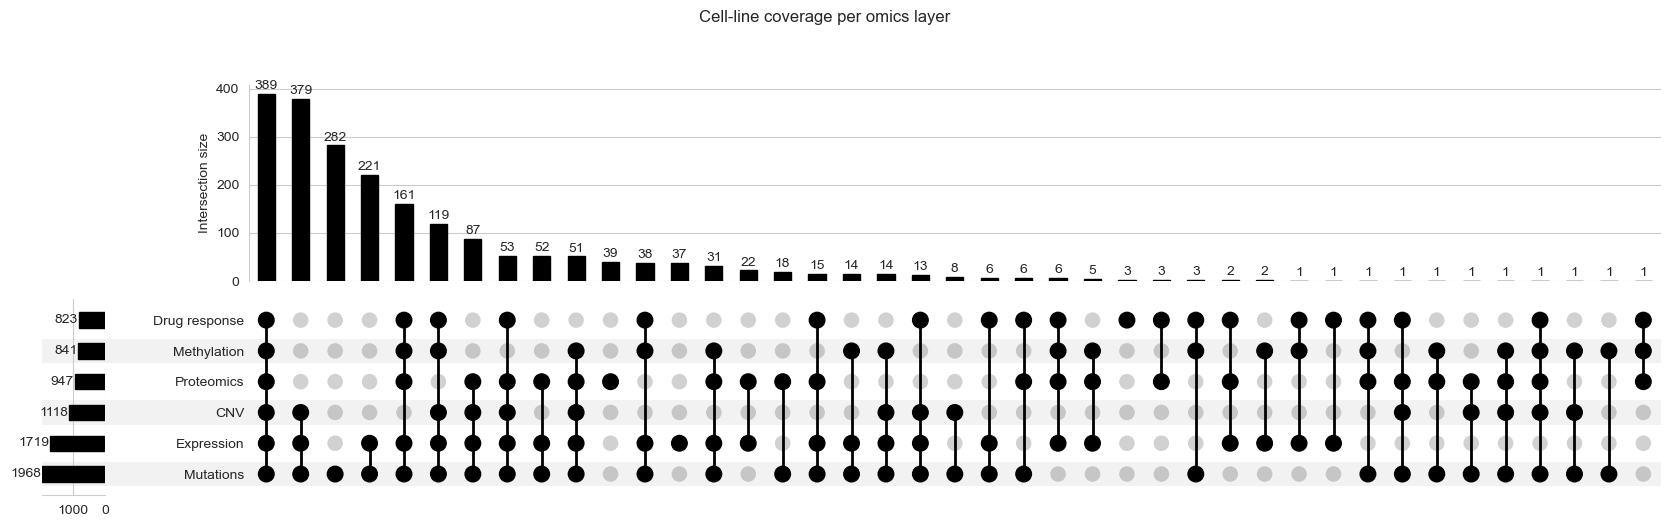

In [65]:
# Optional: UpSet plot if upsetplot is installed
try:
    from upsetplot import UpSet, from_contents
    contents = {
        "Expression":  expr_ids,
        "Mutations":   mut_ids,
        "CNV":         cnv_ids,
        "Methylation": meth_ids,
        "Proteomics":  prot_ids_reference,
        "Drug response": drug_ids,
    }
    upset_data = from_contents(contents)
    fig = plt.figure(figsize=(14, 6))
    UpSet(
        upset_data,
        subset_size="count",
        show_counts=True,
        sort_by="cardinality",
        sort_categories_by="cardinality",
    ).plot(fig)
    plt.suptitle("Cell-line coverage per omics layer", y=1.02)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("upsetplot not installed — skipping UpSet plot")

In [66]:
# Dynamic PRIMARY_CELLS and PROCESSED_DIR based on active layers

# Configuration flags 
INCLUDE_PROTEOMICS  = False
INCLUDE_METHYLATION = False

# Compute PRIMARY_CELLS based on active layers 
base_ids = expr_ids & mut_ids & cnv_ids & drug_ids
if INCLUDE_METHYLATION:
    base_ids = base_ids & meth_ids
if INCLUDE_PROTEOMICS:
    base_ids = base_ids & prot_ids_reference

PRIMARY_CELLS = sorted(base_ids)

# Output directory depends on which layers are included
if INCLUDE_PROTEOMICS and INCLUDE_METHYLATION:
    PROCESSED_DIR = DATA_DIR / "processed"
elif INCLUDE_METHYLATION:
    PROCESSED_DIR = DATA_DIR / "processed_no_prot"
else:
    PROCESSED_DIR = DATA_DIR / "processed_no_prot_no_methyl"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Active layers: expr, mut, cnv"
      + (", meth" if INCLUDE_METHYLATION else "")
      + (", prot" if INCLUDE_PROTEOMICS else ""))
print(f"PRIMARY_CELLS: {len(PRIMARY_CELLS)}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")

# Save to file for downstream notebooks
pd.Series(PRIMARY_CELLS).to_csv(PROCESSED_DIR / "primary_cell_lines.csv",
                                 index=False, header=["ModelID"])
print(f"\nSaved: {PROCESSED_DIR / 'primary_cell_lines.csv'}")

Active layers: expr, mut, cnv
PRIMARY_CELLS: 574
PROCESSED_DIR: data\processed_no_prot_no_methyl

Saved: data\processed_no_prot_no_methyl\primary_cell_lines.csv


## 5. Per-layer cleaning

We process each layer separately: convert to wide format (cell × feature), filter out missing values, and apply appropriate transformations.

### 5.1 Expression — subset to primary cells

In [67]:
expr_clean = expr.loc[expr.index.isin(PRIMARY_CELLS)].copy()
print(f"Expression subset: {expr_clean.shape}")
print(f"  NaN fraction: {expr_clean.isna().mean().mean():.2%}")
expr_clean = expr_clean.dropna(axis=1, how="any")
print(f"  After dropping NaN columns: {expr_clean.shape}")

# Remove genes with virtually zero expression.
MIN_TPM_LOG  = 0.5   # log2(TPM+1) > 0.5 ≈ TPM > 0.41
MIN_FRACTION = 0.20  # expressed in at least 20% of cells
expressed_mask = (expr_clean > MIN_TPM_LOG).mean(axis=0) >= MIN_FRACTION
n_before = expr_clean.shape[1]
expr_clean = expr_clean.loc[:, expressed_mask]
print(f"After low-expression filter (TPM_log>{MIN_TPM_LOG} in >= {MIN_FRACTION:.0%}): "
      f"{n_before} -> {expr_clean.shape[1]} genes")

Expression subset: (574, 19216)
  NaN fraction: 0.00%
  After dropping NaN columns: (574, 19216)
After low-expression filter (TPM_log>0.5 in >= 20%): 19216 -> 14344 genes


### 5.2 Mutations — pivot to wide binary matrix

In [68]:
# Filter to non-silent coding mutations
mut_subset = mut[mut[MODEL_COL].isin(PRIMARY_CELLS)].copy()
print(f"Mutations in primary cells: {len(mut_subset):,} rows")

if EFFECT_COL and EFFECT_COL in mut_subset.columns:
    # Keep only protein-affecting variants
    PROTEIN_AFFECTING_VARIANTS = {
        "Missense_Mutation", "Nonsense_Mutation", "Frame_Shift_Del",
        "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
        "Splice_Site", "Splice_Region", "Nonstop_Mutation", "Translation_Start_Site",
    }
    affecting_lower = {v.lower() for v in PROTEIN_AFFECTING_VARIANTS}
    mut_subset = mut_subset[
        mut_subset[EFFECT_COL].str.lower().isin(affecting_lower)
    ]
    print(f"After filtering to protein-affecting: {len(mut_subset):,} rows")

# Pivot to binary matrix
mut_wide = (mut_subset
            .groupby([MODEL_COL, GENE_COL])
            .size()
            .unstack(fill_value=0)
            .clip(upper=1)
            .astype(np.int8))
# Add missing cell lines as all-zero rows
missing_cells = set(PRIMARY_CELLS) - set(mut_wide.index)
if missing_cells:
    zeros = pd.DataFrame(0, index=list(missing_cells), columns=mut_wide.columns, dtype=np.int8)
    mut_wide = pd.concat([mut_wide, zeros])
mut_wide = mut_wide.loc[PRIMARY_CELLS]
print(f"\nBinary mutation matrix: {mut_wide.shape}")
print(f"Mean mutation rate per gene: {mut_wide.mean().mean():.3%}")

Mutations in primary cells: 573,639 rows
After filtering to protein-affecting: 573,455 rows

Binary mutation matrix: (574, 19530)
Mean mutation rate per gene: 2.616%


### 5.3 CNV — subset

In [69]:
# Keep only numeric columns and restrict rows to the primary cell-line set
cnv_clean = cnv.select_dtypes(include=[np.number]).loc[cnv.index.isin(PRIMARY_CELLS)].copy()

# Identify primary cell lines that are entirely missing from the CNV table
missing = set(PRIMARY_CELLS) - set(cnv_clean.index)
if missing:
    # Add them back as all-NaN rows so the index fully covers PRIMARY_CELLS
    # (NaN here, not 0, since CNV has no natural "zero = no data" semantics)
    nan_rows = pd.DataFrame(np.nan, index=list(missing), columns=cnv_clean.columns)
    cnv_clean = pd.concat([cnv_clean, nan_rows])

# Enforce a fixed row order matching PRIMARY_CELLS for consistency with other omics layers
cnv_clean = cnv_clean.loc[PRIMARY_CELLS]
print(f"CNV subset: {cnv_clean.shape}, NaN fraction: {cnv_clean.isna().mean().mean():.2%}")

# Drop genes (columns) with more than 5% missing values across cell lines 
high_missing = cnv_clean.isna().mean() > 0.05
cnv_clean = cnv_clean.loc[:, ~high_missing]

# Impute remaining (low-rate) missing values with the per-gene median
cnv_clean = cnv_clean.fillna(cnv_clean.median(numeric_only=True))
print(f"After cleaning: {cnv_clean.shape}")

CNV subset: (574, 19956), NaN fraction: 4.06%
After cleaning: (574, 19145)


### 5.4 Methylation — reshape and convert beta → M values

Beta values ∈ [0, 1] are ill-suited for linear models (heteroscedasticity near boundaries). Standard practice is M = log2(β / (1 − β)).

In [72]:
if INCLUDE_METHYLATION:

    def beta_to_m(beta):
        """Convert beta-values to M-values: log2(beta / (1 - beta))."""
        beta = np.asarray(beta, dtype=float)
        beta = np.clip(beta, 1e-6, 1 - 1e-6)  # avoid log(0) at boundaries
        return np.log2(beta / (1 - beta))

    # Separate annotation metadata columns from cell-line columns
    meta_cols_in_file = [c for c in ["locus_id", "CpG_sites_hg19", "avg_coverage"]
                         if c in meth_raw.columns]
    cell_cols = [c for c in meth_raw.columns if c not in meta_cols_in_file]

    # Drop sentinel junk row
    meth_raw = meth_raw[meth_raw["locus_id"].notna() & (meth_raw["locus_id"] != "NA_NA")]

    # Map "HCT116_LARGE_INTESTINE" → "ACH-XXXXXX"; keep only PRIMARY_CELLS
    meth_col_to_model = {c: to_model_id(c.split("_")[0], alias_map) for c in cell_cols}
    meth_col_to_model = {k: v for k, v in meth_col_to_model.items() if v in PRIMARY_CELLS}
    print(f"Methylation columns mappable to primary cells: {len(meth_col_to_model)}")

    # Select matched columns, rename to ModelIDs, set locus_id as feature index
    meth_subset = meth_raw[list(meth_col_to_model.keys())].copy()
    meth_subset.columns = [meth_col_to_model[c] for c in meth_subset.columns]
    meth_subset.index = meth_raw["locus_id"].astype(str)

    # Transpose: (CpG loci × cell lines) → (cell lines × CpG loci)
    meth_wide = meth_subset.T
    print(f"Methylation wide: {meth_wide.shape}")

    # Coerce to float; "NA" strings become NaN
    meth_m = meth_wide.apply(pd.to_numeric, errors="coerce")
    print(f"After to_numeric NaN fraction: {meth_m.isna().mean().mean():.2%}")

    # Drop CpG sites that are entirely NaN
    fully_nan = meth_m.isna().all(axis=0)
    if fully_nan.any():
        print(f"Dropped {fully_nan.sum()} all-NaN columns")
        meth_m = meth_m.loc[:, ~fully_nan]

    # Beta → M-value transformation
    meth_m = pd.DataFrame(
        beta_to_m(meth_m.values),
        index=meth_m.index,
        columns=meth_m.columns
    )
    print(f"M-values: range [{np.nanmin(meth_m.values):.2f}, {np.nanmax(meth_m.values):.2f}]")

    # Drop CpG sites missing in >20% of cell lines
    missing_per_feat = meth_m.isna().mean(axis=0)
    n_before = meth_m.shape[1]
    meth_m = meth_m.loc[:, missing_per_feat < 0.20]
    print(f"Dropped CpG sites with >20% missing: {n_before} -> {meth_m.shape[1]}")

    # Impute remaining NaNs with per-CpG median
    meth_m = meth_m.fillna(meth_m.median())

    # Align to PRIMARY_CELLS; pad missing lines with column mean as last-resort fallback
    meth_m = meth_m.reindex(PRIMARY_CELLS)
    still_missing = meth_m.isna().any(axis=1).sum()
    if still_missing > 0:
        print(f"  {still_missing} cell lines have no methylation data — filling with column mean")
        meth_m = meth_m.fillna(meth_m.mean())

    print(f"Methylation after cleaning: {meth_m.shape}, "
          f"NaN fraction: {meth_m.isna().mean().mean():.4%}")

else:
    meth_m = None
    print("Methylation excluded.")

Methylation excluded.


### 5.5 Proteomics

In [73]:
if INCLUDE_PROTEOMICS:

    prot_clean = prot.copy()

    # Remap index to canonical ModelIDs if not already in ACH-XXXXXX format
    sample = prot_clean.index[0] if len(prot_clean) else None
    if sample and not str(sample).startswith("ACH-"):
        new_index = [to_model_id(s, alias_map) for s in prot_clean.index]
        prot_clean.index = new_index
        prot_clean = prot_clean[prot_clean.index.notna()]           # drop unmapped
        prot_clean = prot_clean[~prot_clean.index.duplicated(keep="first")]

    # Restrict to PRIMARY_CELLS; pad missing lines with NaN rows
    prot_clean = prot_clean.loc[prot_clean.index.isin(PRIMARY_CELLS)]
    missing = set(PRIMARY_CELLS) - set(prot_clean.index)
    if missing:
        nan_rows = pd.DataFrame(np.nan, index=list(missing), columns=prot_clean.columns)
        prot_clean = pd.concat([prot_clean, nan_rows])
    prot_clean = prot_clean.loc[PRIMARY_CELLS]

    # Drop proteins missing in >30% of lines (looser than meth 20% — MS is sparser)
    high_missing = prot_clean.isna().mean() > 0.30
    prot_clean = prot_clean.loc[:, ~high_missing]

    # Impute remaining NaNs with per-protein median
    prot_clean = prot_clean.fillna(prot_clean.median())

    print(f"Proteomics clean: {prot_clean.shape}")

else:
    prot_clean = None
    print("Proteomics excluded.")

Proteomics excluded.


## 6. Feature selection (top variable features)

We select the most variable features per layer as a pre-filter to reduce dimensionality before downstream modeling. This is a per-layer step — no standardization is applied here.

The `standardize()` function has been removed entirely from this notebook. It is performed inside the CV pipeline in `02_model_development_v4.ipynb` using `StandardScaler` fitted only on training data per fold, preventing data leakage.

In [74]:
FEATURE_BUDGETS = {
    "expression":  5000,
    "cnv":         5000,
    "mutations":   1000,
    "methylation": 5000,
    "proteomics":  3000,
}

def top_variable_features(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Keep the n features with highest variance across cell lines."""
    if df.shape[1] <= n:
        return df
    var = df.var(axis=0)
    top_cols = var.nlargest(n).index
    return df[top_cols]

# Select top variable features per layer (raw, not standardized)
expr_top  = top_variable_features(expr_clean,  FEATURE_BUDGETS["expression"])
cnv_top   = top_variable_features(cnv_clean,   FEATURE_BUDGETS["cnv"])

print(f"Expression top features: {expr_top.shape}")
print(f"CNV top features:        {cnv_top.shape}")

Expression top features: (574, 5000)
CNV top features:        (574, 5000)


We now also add an upper bound to remove near-universal mutations which provide no discriminative power.

In [75]:
# Mutation frequency filter with upper bound
MIN_MUT_FREQ = 0.01   # mutation present in >= 1% of cells (removes noise)
MAX_MUT_FREQ = 0.85   # mutation present in <= 85% of cells (removes near-universal, uninformative)

min_mut_count = max(1, int(MIN_MUT_FREQ * len(PRIMARY_CELLS)))
max_mut_count = int(MAX_MUT_FREQ * len(PRIMARY_CELLS))

mut_freq = mut_wide.sum(axis=0)
freq_mask = (mut_freq >= min_mut_count) & (mut_freq <= max_mut_count)
mut_freq_filtered = mut_freq[freq_mask].sort_values(ascending=False)

print(f"Mutation frequency filter [{MIN_MUT_FREQ:.0%}, {MAX_MUT_FREQ:.0%}]: "
      f"{mut_wide.shape[1]} -> {freq_mask.sum()} genes")

mut_top = mut_wide[mut_freq_filtered.head(FEATURE_BUDGETS["mutations"]).index]
print(f"Final mutation matrix: {mut_top.shape}")

Mutation frequency filter [1%, 85%]: 19530 -> 16030 genes
Final mutation matrix: (574, 1000)


In [76]:
# Methylation top variable features (only if included)
if INCLUDE_METHYLATION and meth_m is not None:
    meth_top = top_variable_features(meth_m, FEATURE_BUDGETS["methylation"])
    print(f"Methylation top features: {meth_top.shape}")
else:
    meth_top = None
    print("Methylation not included.")

# Proteomics top variable features (only if included)
if INCLUDE_PROTEOMICS and prot_clean is not None:
    prot_top = top_variable_features(prot_clean, FEATURE_BUDGETS["proteomics"])
    print(f"Proteomics top features: {prot_top.shape}")
else:
    prot_top = None
    print("Proteomics not included.")

Methylation not included.
Proteomics not included.


## 7. Lineage handling — no residualization

we do **not** residualize omics layers against tissue-of-origin. Removing the lineage component from expression risks discarding genuine predictive biology, since drug sensitivity is itself substantially a function of tissue/subtype. Instead, lineage is carried forward as metadata (`cell_metadata.parquet`) and supplied to the model in notebook 2 as an explicit one-hot feature block. This lets the regularized model decide how much weight tissue deserves, keeps every omics layer on equal footing (no asymmetric expr-corrected / CNV-raw treatment), and removes the preprocessing-leakage concern of fitting an OLS residualizer across train+test cells.

The `expr_top` / `cnv_top` / `mut_top` matrices below are saved raw (feature-selected, log-scaled where applicable, but not lineage-corrected). `StandardScaler` is applied per-fold inside the CV pipeline in notebook 2.

In [77]:
# Keep the *_corrected names as aliases so downstream EDA cells are untouched,
# but they now hold the raw (feature-selected) matrices.
expr_corrected = expr_top
cnv_corrected  = cnv_top
mut_corrected  = mut_top

if INCLUDE_METHYLATION and meth_top is not None:
    meth_corrected = meth_top
else:
    meth_corrected = None

if INCLUDE_PROTEOMICS and prot_top is not None:
    prot_corrected = prot_top
else:
    prot_corrected = None

# lineage_series is still useful for EDA colouring / within-lineage checks
lineage_series = (
    model_meta.set_index("ModelID")["OncotreeLineage"]
    .reindex(PRIMARY_CELLS)
    .fillna("Unknown")
)

print("v4: no residualization applied — layers passed through raw.")
print(f"  Expression: {expr_corrected.shape}")
print(f"  CNV:        {cnv_corrected.shape}")
print(f"  Mutations:  {mut_corrected.shape}")


v4: no residualization applied — layers passed through raw.
  Expression: (574, 5000)
  CNV:        (574, 5000)
  Mutations:  (574, 1000)


## B. EDA
## 1. Dataset overview table

In [78]:
def layer_summary(name, df):
    return {
        "Layer": name,
        "Samples": df.shape[0],
        "Features": df.shape[1],
        "Missing (%)": round(
            100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1]),
            2
        )
    }

overview_rows = [
    layer_summary("Expression", expr_corrected),
    layer_summary("Mutations", mut_top),
    layer_summary("CNV", cnv_corrected),
]
if INCLUDE_METHYLATION and meth_corrected is not None:
    overview_rows.append(layer_summary("Methylation", meth_corrected))
if INCLUDE_PROTEOMICS and prot_corrected is not None:
    overview_rows.append(layer_summary("Proteomics", prot_corrected))

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

,Layer,Samples,Features,Missing (%)
0,Expression,574,5000,0.0
1,Mutations,574,1000,0.0
2,CNV,574,5000,0.0


In [79]:
print("CTRPv2 Overview")
print("-" * 50)
print(f"Unique cell lines : {df_ctrp['cell_line_uid'].nunique():,}")
print(f"Unique compounds  : {df_ctrp['compound_id'].nunique():,}")
print(f"Total experiments : {len(df_ctrp):,}")
print("\nDrug response missingness:")
for metric in ["AAC", "IC50", "EC50", "HS", "Einf"]:
    missing_pct = 100 * df_ctrp[metric].isna().mean()
    print(f"  {metric:<5}: {missing_pct:.2f}%")

CTRPv2 Overview
--------------------------------------------------
Unique cell lines : 887
Unique compounds  : 544
Total experiments : 395,263

Drug response missingness:
  AAC  : 6.12%
  IC50 : 37.95%
  EC50 : 6.12%
  HS   : 6.12%
  Einf : 6.12%


## 2. UMAP per layer

UMAP of each layer individually, colored by `OncotreeLineage`. The goal is to see how well each omics layer captures the tissue-of-origin structure.

UMAP uses Euclidean distance for continuous layers (expression, CNV, methylation, proteomics) and **Jaccard distance** for mutations (correct for sparse binary data). For UMAP visualization only, a local StandardScaler is applied to continuous layers (not saved) since UMAP requires normalized input.

In [80]:
import umap
from sklearn.preprocessing import StandardScaler as _SS

# Build a lineage lookup for the primary cell lines
lineage = (model_meta.set_index("ModelID")["OncotreeLineage"]
           .reindex(PRIMARY_CELLS)
           .fillna("Unknown"))

# Reduce to top 15 lineages for plotting clarity
top_lineages = lineage.value_counts().head(15).index
lineage_plot = lineage.where(lineage.isin(top_lineages), "Other")

# Apply StandardScaler locally for UMAP only
expr_corrected_std_for_umap = pd.DataFrame(
    _SS().fit_transform(expr_corrected.values),
    index=expr_corrected.index, columns=expr_corrected.columns
)
cnv_corrected_std_for_umap = pd.DataFrame(
    _SS().fit_transform(cnv_corrected.values),
    index=cnv_corrected.index, columns=cnv_corrected.columns
)

embeddings = {}

# Expression and CNV use Euclidean distance
for name, df in [("Expression", expr_corrected_std_for_umap),
                 ("CNV",        cnv_corrected_std_for_umap)]:
    reducer = umap.UMAP(metric="euclidean", n_neighbors=15, min_dist=0.3,
                        random_state=RANDOM_STATE, n_components=2)
    embeddings[name] = reducer.fit_transform(df.values)

# Mutations use Jaccard distance (correct for sparse binary data)
reducer_mut = umap.UMAP(metric="jaccard", n_neighbors=15, min_dist=0.3,
                         random_state=RANDOM_STATE, n_components=2)
embeddings["Mutations"] = reducer_mut.fit_transform(mut_top.values.astype(np.float32))

if INCLUDE_METHYLATION and meth_corrected is not None:
    meth_std_for_umap = pd.DataFrame(
        _SS().fit_transform(meth_corrected.values),
        index=meth_corrected.index, columns=meth_corrected.columns
    )
    reducer = umap.UMAP(metric="euclidean", n_neighbors=15, min_dist=0.3,
                        random_state=RANDOM_STATE, n_components=2)
    embeddings["Methylation"] = reducer.fit_transform(meth_std_for_umap.values)

if INCLUDE_PROTEOMICS and prot_corrected is not None:
    prot_std_for_umap = pd.DataFrame(
        _SS().fit_transform(prot_corrected.values),
        index=prot_corrected.index, columns=prot_corrected.columns
    )
    reducer = umap.UMAP(metric="euclidean", n_neighbors=15, min_dist=0.3,
                        random_state=RANDOM_STATE, n_components=2)
    embeddings["Proteomics"] = reducer.fit_transform(prot_std_for_umap.values)

print(f"UMAP embeddings computed for: {list(embeddings.keys())}")

UMAP embeddings computed for: ['Expression', 'CNV', 'Mutations']


In [81]:
# Check for duplicates only in active layers.
active_layers = [
    ("expr_corrected", expr_corrected),
    ("mut_top",        mut_top),
    ("cnv_corrected",  cnv_corrected),
]
if INCLUDE_METHYLATION and meth_corrected is not None:
    active_layers.append(("meth_corrected", meth_corrected))
if INCLUDE_PROTEOMICS and prot_corrected is not None:
    active_layers.append(("prot_corrected", prot_corrected))

for name, df in active_layers:
    dup = df.index.duplicated().sum()
    print(f"{name:<18} shape={df.shape}, duplicates={dup}")

expr_corrected     shape=(574, 5000), duplicates=0
mut_top            shape=(574, 1000), duplicates=0
cnv_corrected      shape=(574, 5000), duplicates=0


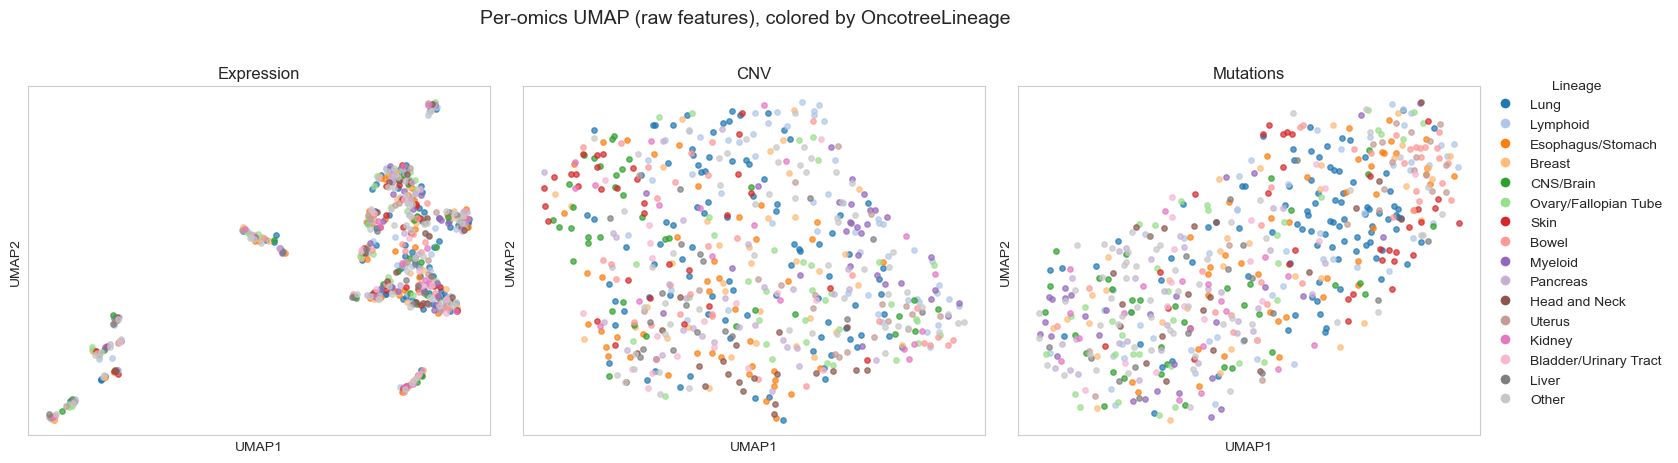

In [82]:
# Plot UMAPs side by side
n_layers = len(embeddings)
n_cols = 3
n_rows = (n_layers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten() if n_layers > 1 else [axes]

palette = sns.color_palette("tab20", n_colors=len(top_lineages) + 1)
color_map = dict(zip(list(top_lineages) + ["Other"], palette))

for ax, (name, emb) in zip(axes, embeddings.items()):
    for lin in list(top_lineages) + ["Other"]:
        mask = (lineage_plot == lin).values
        ax.scatter(emb[mask, 0], emb[mask, 1], s=15, alpha=0.7,
                   color=color_map[lin], label=lin if name == "Expression" else None)
    ax.set_title(name)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(embeddings):]:
    ax.axis("off")

handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=color_map[l], markersize=8, label=l)
           for l in list(top_lineages) + ["Other"]]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title="Lineage", frameon=False)
plt.suptitle("Per-omics UMAP (raw features), colored by OncotreeLineage", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Cross-omics PC correlation

Concatenated PC matrix: (574, 30)


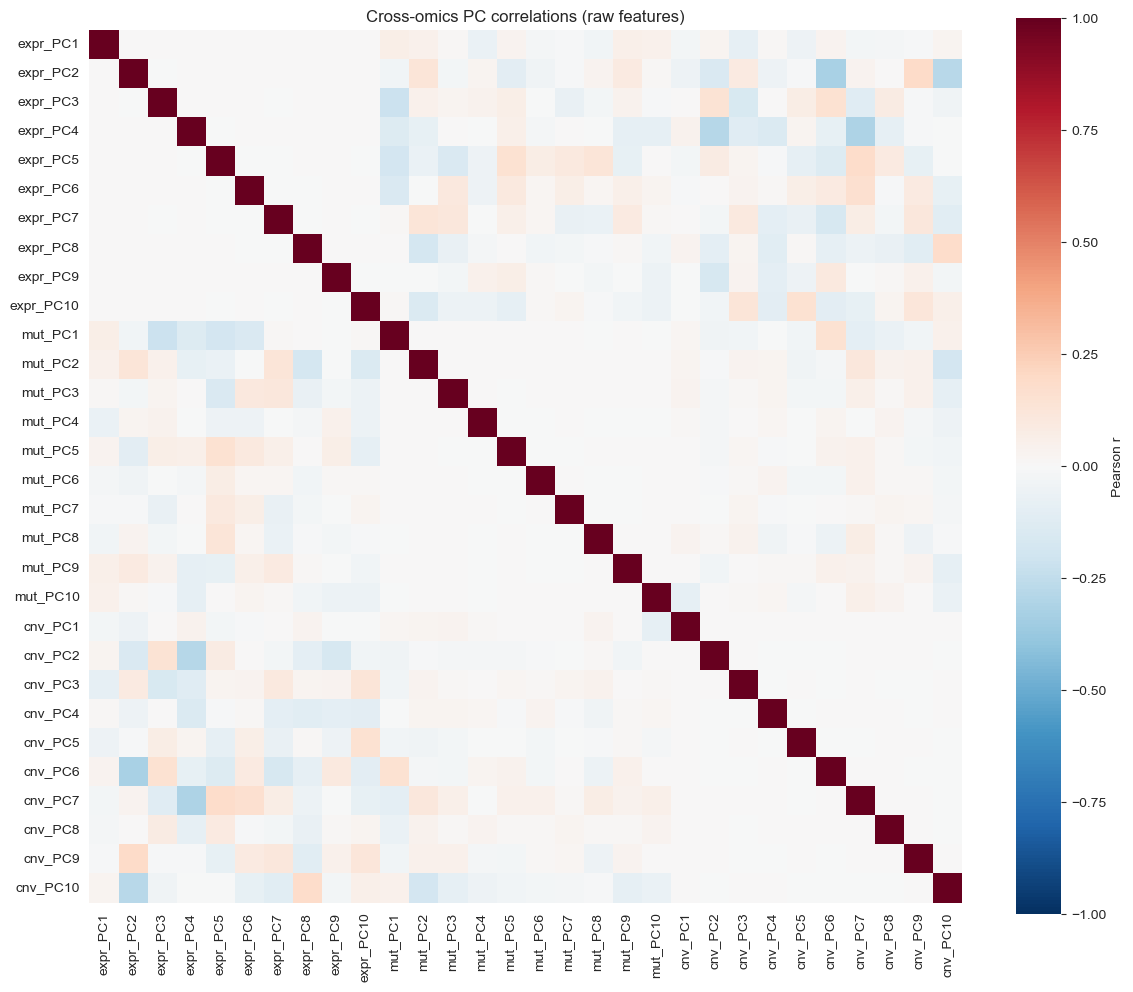

In [83]:
from sklearn.decomposition import PCA

def top_pcs(X: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    pca = PCA(n_components=n, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X.values)
    return pd.DataFrame(pcs, index=X.index,
                        columns=[f"PC{i+1}" for i in range(n)])

layers_for_pca = {
    "expr": expr_corrected,
    "mut":  mut_top.astype(float),
    "cnv":  cnv_corrected,
}
if INCLUDE_METHYLATION and meth_corrected is not None:
    layers_for_pca["meth"] = meth_corrected
if INCLUDE_PROTEOMICS and prot_corrected is not None:
    layers_for_pca["prot"] = prot_corrected

pcs_per_layer = {name: top_pcs(X, n=10) for name, X in layers_for_pca.items()}

all_pcs = pd.concat({k: v for k, v in pcs_per_layer.items()}, axis=1)
all_pcs.columns = [f"{layer}_{pc}" for layer, pc in all_pcs.columns]
print(f"Concatenated PC matrix: {all_pcs.shape}")

corr = all_pcs.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"})
plt.title("Cross-omics PC correlations (raw features)")
plt.tight_layout()
plt.show()

## 4. Drug response landscape

In [84]:
# Map drug response cell lines to ModelID, subset to primary cells
drugs["ModelID"] = drugs["cell_line"].apply(lambda x: to_model_id(x, alias_map))
drugs_primary = drugs[drugs["ModelID"].isin(PRIMARY_CELLS)].copy()
print(f"Drug response in primary cells: {len(drugs_primary):,} rows")
print(f"Unique compounds: {drugs_primary['compound'].nunique()}")
print(f"Mean AAC: {drugs_primary['AAC'].mean():.3f}")

Drug response in primary cells: 259,635 rows
Unique compounds: 544
Mean AAC: 0.150


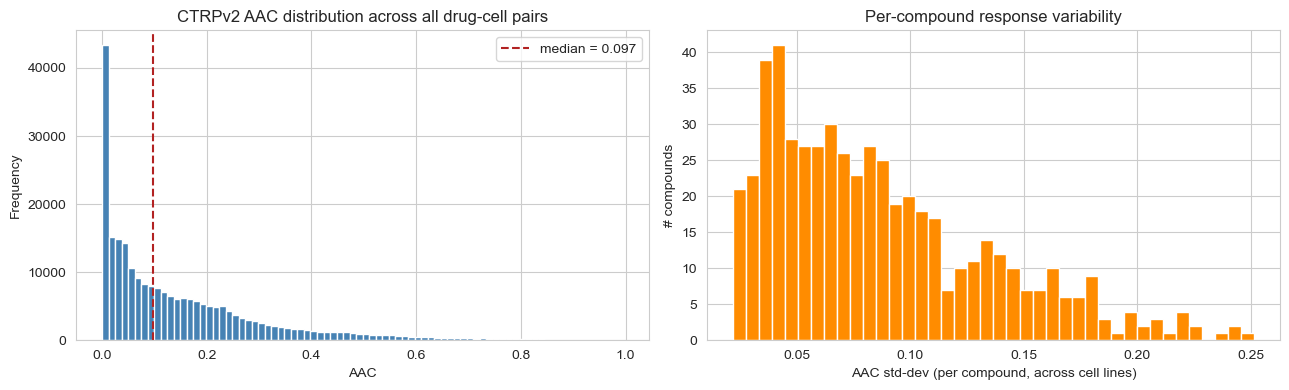

In [85]:
# AAC distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(drugs_primary["AAC"].dropna(), bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("AAC")
axes[0].set_ylabel("Frequency")
axes[0].set_title("CTRPv2 AAC distribution across all drug-cell pairs")
axes[0].axvline(drugs_primary["AAC"].median(), color="firebrick", linestyle="--",
                label=f"median = {drugs_primary['AAC'].median():.3f}")
axes[0].legend()

drug_var = drugs_primary.groupby("compound")["AAC"].std().sort_values(ascending=False)
axes[1].hist(drug_var.dropna(), bins=40, color="darkorange", edgecolor="white")
axes[1].set_xlabel("AAC std-dev (per compound, across cell lines)")
axes[1].set_ylabel("# compounds")
axes[1].set_title("Per-compound response variability")
plt.tight_layout()
plt.show()

### Drug response matrix (cells × compounds)

For the model, we will need a pivot table: rows = cell lines, columns = compounds, values = AAC.

In [86]:
agg = drugs_primary.groupby(["ModelID", "compound"]).agg(
    aac_mean=("AAC", "mean"),
    aac_std=("AAC", "std"),
    n_reps=("AAC", "count"),
).reset_index()

drug_matrix = agg.pivot(index="ModelID", columns="compound", values="aac_mean")
drug_matrix.columns.name = None

print(f"Drug matrix shape: {drug_matrix.shape}")
print(f"  Sparsity (NaN fraction): {drug_matrix.isna().mean().mean():.1%}")

Drug matrix shape: (574, 544)
  Sparsity (NaN fraction): 24.0%


## Save processed matrices

We save the **raw** feature matrices (feature-selected, not standardized, not lineage-corrected) to parquet. `StandardScaler` is applied inside the CV pipeline in `02_model_development_v4.ipynb`. Lineage is saved separately in `cell_metadata.parquet` and added as an explicit one-hot feature block in notebook 2.

In [87]:
# Save raw (not standardized, not lineage-corrected) feature matrices to parquet.
# StandardScaler is applied inside the CV pipeline in 02_model_development_v4.ipynb.
# expr_corrected/cnv_corrected/etc. are aliases for the raw *_top matrices (v4).
to_save = {
    "expression":    expr_corrected,    # raw, feature-selected (alias of expr_top)
    "mutations":     mut_top,            # raw binary, not corrected (binary — OLS not appropriate)
    "cnv":           cnv_corrected,      # raw continuous, feature-selected (alias of cnv_top)
    "drug_response": drug_matrix,
}
if INCLUDE_METHYLATION and meth_corrected is not None:
    to_save["methylation"] = meth_corrected   # raw, feature-selected
if INCLUDE_PROTEOMICS and prot_corrected is not None:
    to_save["proteomics"] = prot_corrected     # raw, feature-selected

for name, df in to_save.items():
    out = PROCESSED_DIR / f"{name}.parquet"
    df.reset_index().rename(columns={"index": "ModelID"}).to_parquet(out, index=False)
    print(f"  Saved: {out.name:<25} {df.shape}")

# Also save metadata
model_meta.loc[model_meta["ModelID"].isin(PRIMARY_CELLS)].to_parquet(
    PROCESSED_DIR / "cell_metadata.parquet", index=False
)
print(f"  Saved: cell_metadata.parquet")

print(f"\nAll processed files in: {PROCESSED_DIR.resolve()}")
for p in sorted(PROCESSED_DIR.glob("*.parquet")):
    size_mb = p.stat().st_size / 1024**2
    print(f"  {p.name:<35} {size_mb:>7.2f} MB")

  Saved: expression.parquet        (574, 5000)
  Saved: mutations.parquet         (574, 1000)
  Saved: cnv.parquet               (574, 5000)
  Saved: drug_response.parquet     (574, 544)
  Saved: cell_metadata.parquet

All processed files in: C:\Users\pikil\Multi-Omics-Mechanism-Modelling-AAC\data\processed_no_prot_no_methyl
  cell_metadata.parquet                  0.03 MB
  cnv.parquet                           27.95 MB
  drug_response.parquet                  2.24 MB
  expression.parquet                    27.34 MB
  mutations.parquet                      0.56 MB
